#### agreggation du sentiment au niveau journalier 

In [1]:
import pandas as pd
import numpy as np
import os

DATA_DIR = "data/raw"
FILE_FR = "finbert_articles_fr_final2026.csv"
FILE_DE = "finbert_articles_de_final2026.csv"
# Nouveau nom de fichier en sortie
OUTPUT_FILE = "aggregated_daily_finbert_norm.csv"

def load_and_aggregate_daily(filename):
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path)

    col_date = 'date'
    # Conversion en Datetime UTC, puis suppression de la Timezone et de l'heure
    df['dt'] = pd.to_datetime(df[col_date], utc=True, errors='coerce')
    df['date_clean'] = df['dt'].dt.tz_localize(None).dt.normalize()
    
    # Agrégation : Moyenne des scores pour chaque jour
    daily_series = df.groupby('date_clean')['sentiment_score'].mean()
    return daily_series

sent_fr = load_and_aggregate_daily(FILE_FR)
sent_de = load_and_aggregate_daily(FILE_DE)

start_date = min(sent_fr.index.min(), sent_de.index.min())
end_date = max(sent_fr.index.max(), sent_de.index.max())
full_index = pd.date_range(start=start_date, end=end_date, freq='D')
    
df_aligned = pd.DataFrame(index=full_index)
df_aligned.index.name = 'date'

df_aligned['sent_fr'] = sent_fr
df_aligned['sent_de'] = sent_de
    
# IMPUTATION DES DONNÉES MANQUANTES (Week-ends / Jours sans news)
df_aligned = df_aligned.interpolate(method='time', limit=5)

# ==========================================
# NORMALISATION (Z-SCORE : Moyenne 0, Std 1)
# ==========================================
df_aligned['sent_fr_norm'] = (df_aligned['sent_fr'] - df_aligned['sent_fr'].mean()) / df_aligned['sent_fr'].std()
df_aligned['sent_de_norm'] = (df_aligned['sent_de'] - df_aligned['sent_de'].mean()) / df_aligned['sent_de'].std()

# DIFFERENTIEL NORMALISÉ
df_aligned['sentiment_diff_norm'] = df_aligned['sent_fr_norm'] - df_aligned['sent_de_norm']
    
# ==========================================
# LISSAGE (Moyennes mobiles 7 jours)
# ==========================================
# On garde les lissages sur les données brutes au cas où
df_aligned['sent_fr_ma7'] = df_aligned['sent_fr'].rolling(7).mean()
df_aligned['sent_de_ma7'] = df_aligned['sent_de'].rolling(7).mean()

# Et on ajoute les lissages sur les données normalisées
df_aligned['sent_fr_norm_ma7'] = df_aligned['sent_fr_norm'].rolling(7).mean()
df_aligned['sent_de_norm_ma7'] = df_aligned['sent_de_norm'].rolling(7).mean()
df_aligned['diff_norm_ma7'] = df_aligned['sentiment_diff_norm'].rolling(7).mean()

out_path = os.path.join(DATA_DIR, OUTPUT_FILE)
df_aligned.to_csv(out_path)

print(f"✅ Fichier normalisé exporté : {out_path}")

✅ Fichier normalisé exporté : data/raw\aggregated_daily_finbert_norm.csv


#### graphs

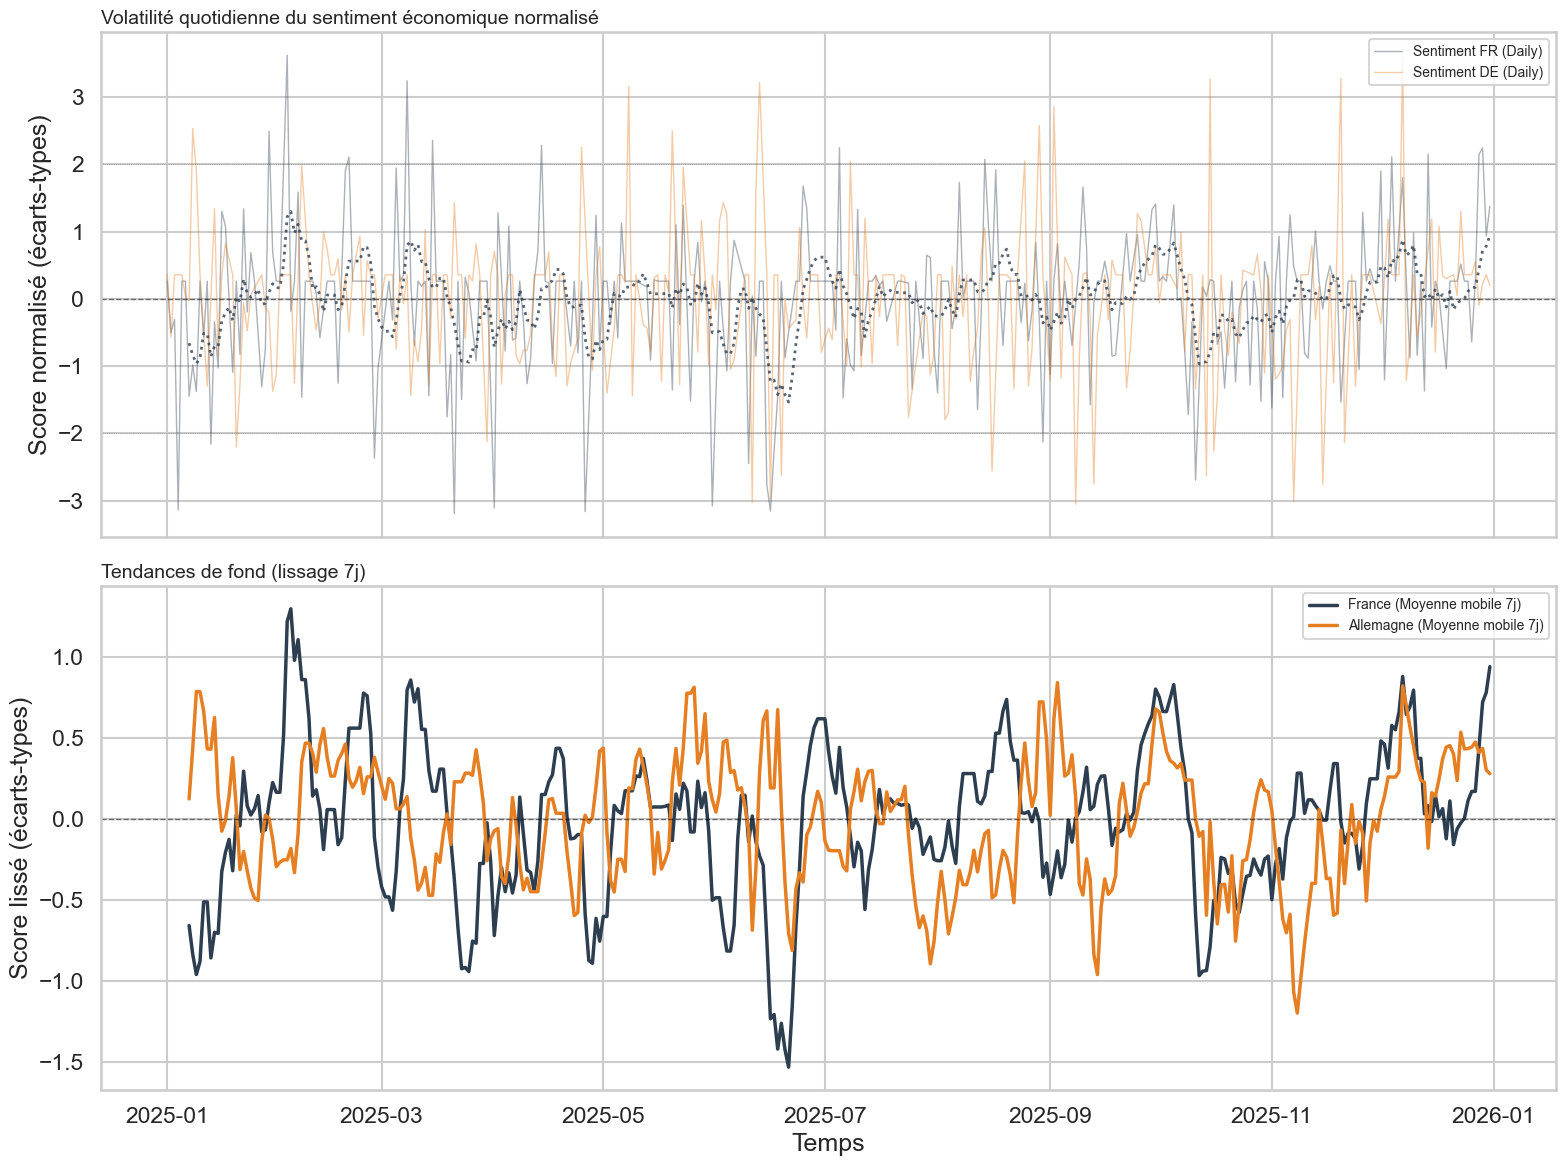

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_DIR = "data/raw"
INPUT_FILE = "aggregated_daily_finbert_norm.csv"
path = os.path.join(DATA_DIR, INPUT_FILE)
df = pd.read_csv(path, index_col=0, parse_dates=True)
    
# --- DATES À DÉFINIR ICI ---
START_DATE = df.index.min()
END_DATE = df.index.max()
# START_DATE = pd.Timestamp("2020-01-01")
# END_DATE = pd.Timestamp("2020-01-31")

mask = (df.index >= START_DATE) & (df.index <= END_DATE)
plot_df = df.loc[mask]

# ==========================================
# 2. GRAPHIQUE DOUBLE (BRUT vs LISSÉ)
# ==========================================
sns.set_theme(style="whitegrid", context="talk") # Style académique pour les papiers
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# COULEURS (Palette académique)
col_fr = '#2c3e50'  # Bleu sombre (France)
col_de = '#e67e22'  # Orange (Allemagne)

# --- GRAPHIQUE 1 : Sentiment Journalier (Volatil) ---
ax1.plot(plot_df.index, plot_df['sent_fr_norm'], color=col_fr, alpha=0.4, linewidth=1, label='Sentiment FR (Daily)')
ax1.plot(plot_df.index, plot_df['sent_de_norm'], color=col_de, alpha=0.4, linewidth=1, label='Sentiment DE (Daily)')

# Attention au titre : seule la première lettre en majuscule !
ax1.set_title("Volatilité quotidienne du sentiment économique normalisé", fontsize=14, loc='left')
ax1.set_ylabel("Score normalisé (écarts-types)")
ax1.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)

# Ajout des bornes -2 et +2 pour visualiser les vraies crises (optionnel mais visuel)
ax1.axhline(2, color='gray', linewidth=0.5, linestyle=':')
ax1.axhline(-2, color='gray', linewidth=0.5, linestyle=':')

ax1.legend(loc='upper right', frameon=True, fontsize=10)

# --- GRAPHIQUE 2 : Tendance Hebdomadaire (MA7 - Signal Macro) ---
if 'sent_fr_norm_ma7' in plot_df.columns:
    ax1.plot(plot_df.index, plot_df['sent_fr_norm_ma7'], color=col_fr, linewidth=2, linestyle=':', alpha=0.8, label='_nolegend_') 
        
    ax2.plot(plot_df.index, plot_df['sent_fr_norm_ma7'], color=col_fr, linewidth=2.5, label='France (Moyenne mobile 7j)')
    ax2.plot(plot_df.index, plot_df['sent_de_norm_ma7'], color=col_de, linewidth=2.5, label='Allemagne (Moyenne mobile 7j)')
    
    # Titre formaté
    ax2.set_title("Tendances de fond (lissage 7j)", fontsize=14, loc='left')
    ax2.set_ylabel("Score lissé (écarts-types)")
    ax2.set_xlabel("Temps")
    ax2.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    
    ax2.legend(loc='upper right', frameon=True, fontsize=10)

    plt.tight_layout()
    plt.show()

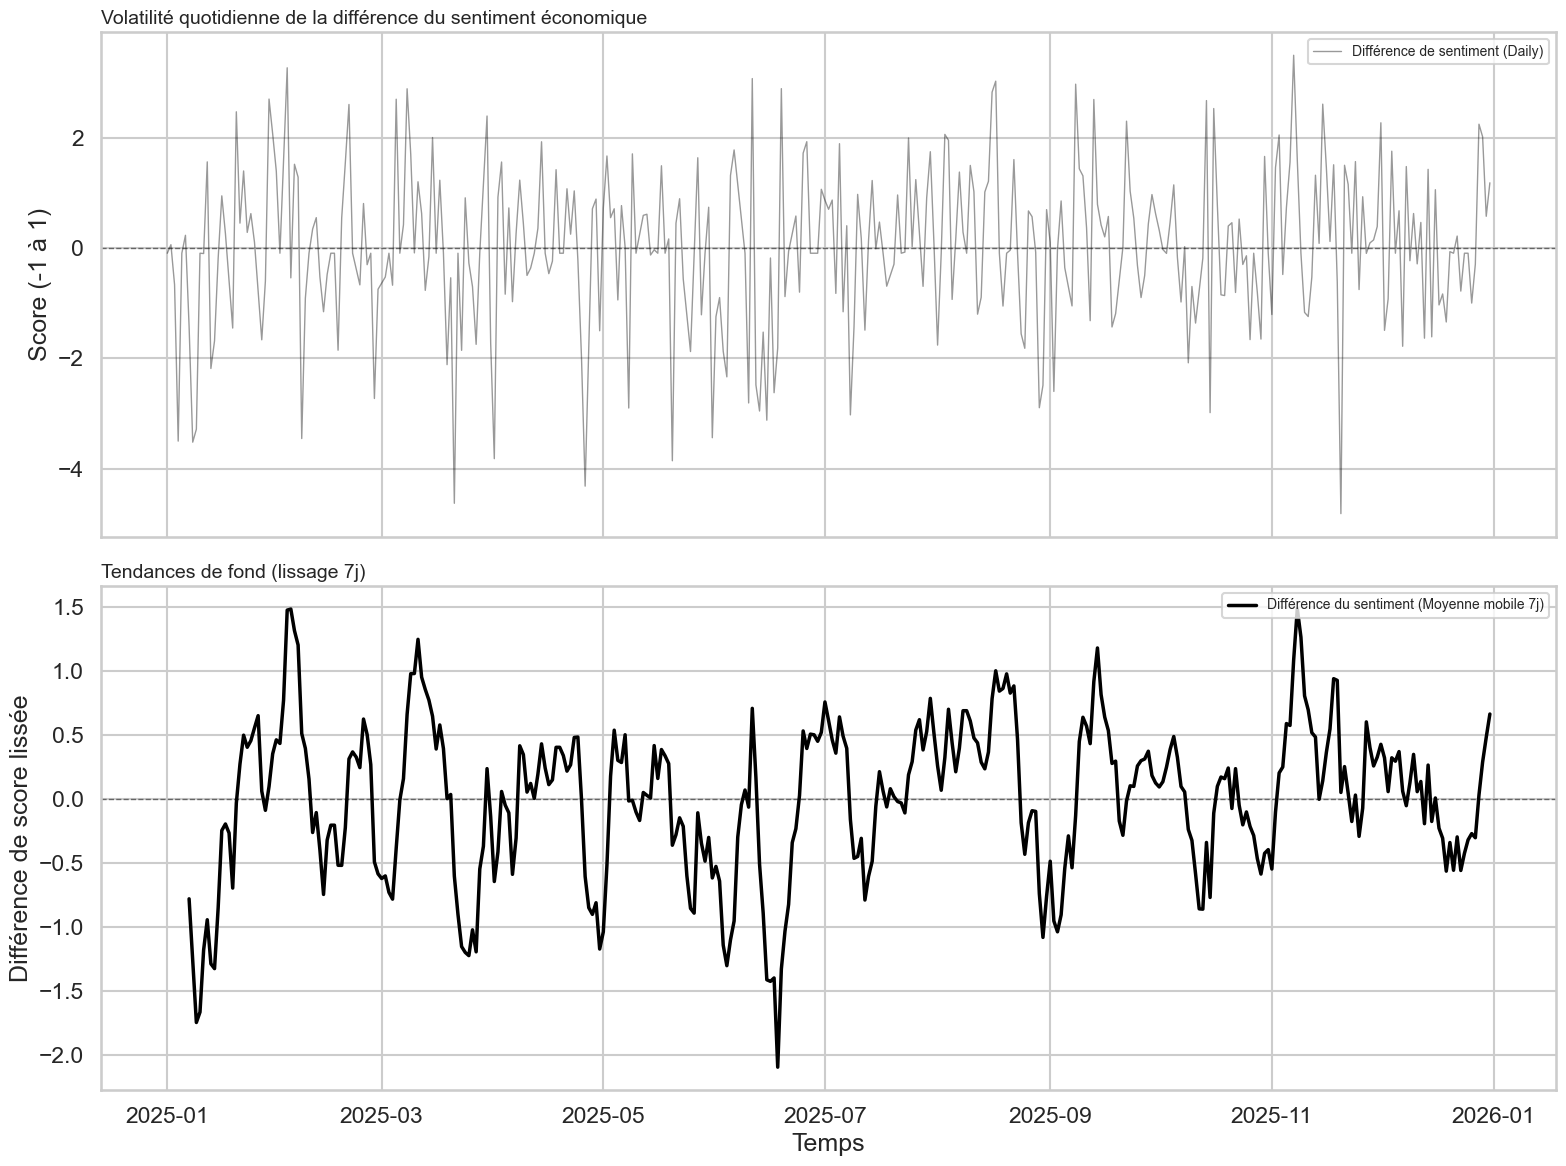

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_DIR = "data/raw"
INPUT_FILE = "aggregated_daily_finbert_norm.csv"
path = os.path.join(DATA_DIR, INPUT_FILE)
df = pd.read_csv(path, index_col=0, parse_dates=True)
    
    # --- DATES À DÉFINIR ICI ---
    # Pour zoomer, remplace par : pd.Timestamp("2022-01-01")
START_DATE = df.index.min()
END_DATE = df.index.max()
# START_DATE = pd.Timestamp("2020-01-01")
# END_DATE = pd.Timestamp("2020-01-31")

mask = (df.index >= START_DATE) & (df.index <= END_DATE)
plot_df = df.loc[mask]

    # ==========================================
    # 2. GRAPHIQUE DOUBLE (BRUT vs LISSÉ)
    # ==========================================
sns.set_theme(style="whitegrid", context="talk") # Style "Papier de recherche"
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)


    # --- GRAPHIQUE 1 : Sentiment Journalier (Volatil) ---
ax1.plot(plot_df.index, plot_df['sentiment_diff_norm'], color='black', alpha=0.4, linewidth=1, label='Différence de sentiment (Daily)')
ax1.set_title("Volatilité quotidienne de la différence du sentiment économique", fontsize=14, loc='left')
ax1.set_ylabel("Score (-1 à 1)")
ax1.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right', frameon=True, fontsize=10)

    # --- GRAPHIQUE 2 : Tendance Hebdomadaire (MA7 - Signal Macro) ---
    # C'est ce signal que ton modèle économétrique va probablement utiliser
if 'diff_norm_ma7' in plot_df.columns:
        
    ax2.plot(plot_df.index, plot_df['diff_norm_ma7'], color='black', linewidth=2.5, label='Différence du sentiment (Moyenne mobile 7j)')
    
    ax2.set_title("Tendances de fond (lissage 7j)", fontsize=14, loc='left')
    ax2.set_ylabel("Différence de score lissée")
    ax2.set_xlabel("Temps")
    ax2.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
        
    ax2.legend(loc='upper right', frameon=True, fontsize=10)

    plt.tight_layout()
    plt.show()

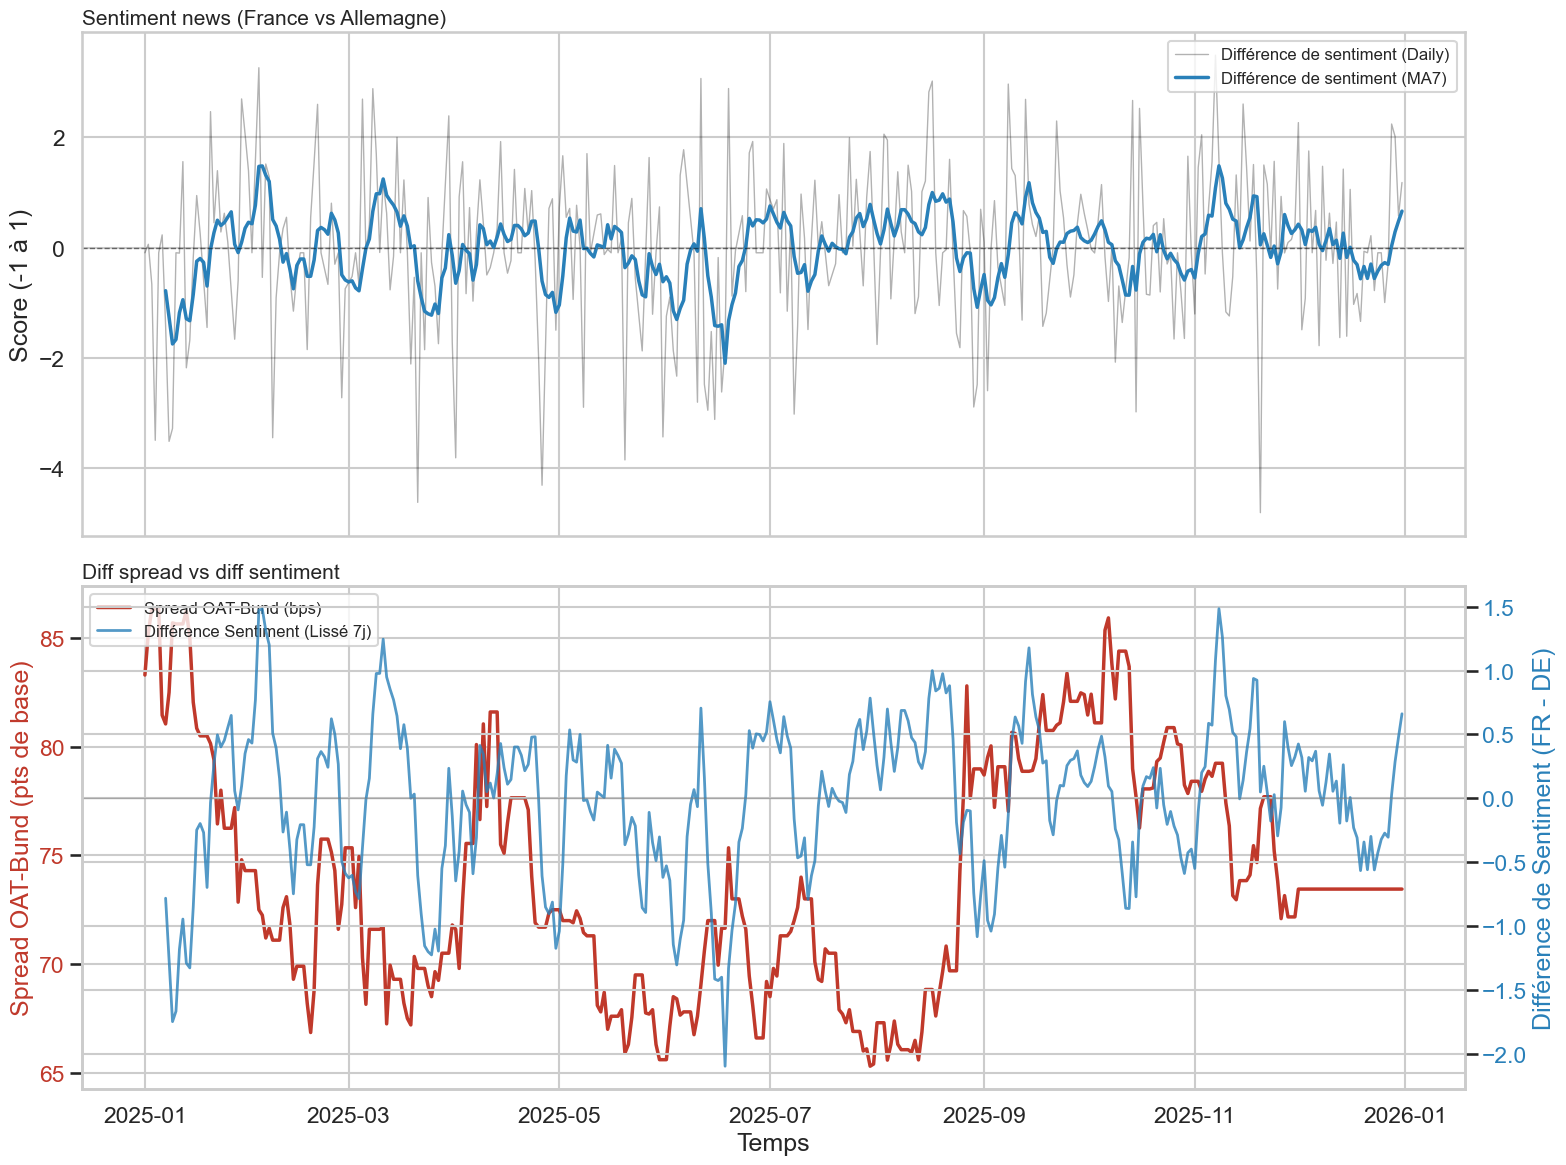

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# 1. CONFIGURATION ET CHARGEMENT
# ==========================================
DATA_DIR = "data/raw" # Adapte si tes fichiers de taux sont juste dans "data"
SENTIMENT_FILE = "aggregated_daily_finbert_norm.csv"
BOND_FR_FILE = "Rendement de l'Obligation France 10 ans - Données Historiques (1).csv"
BOND_DE_FILE = "Rendement de l'Obligation Allemagne 10 ans - Données Historiques.csv"

# --- A. Chargement du Sentiment ---
path_sent = os.path.join(DATA_DIR, SENTIMENT_FILE)
df_sent = pd.read_csv(path_sent, index_col=0, parse_dates=True)

# Recalcul de la différence si elle n'est pas déjà dans le CSV
if 'sentiment_diff_norm' not in df_sent.columns:
    df_sent['sentiment_diff'] = df_sent['sentiment_moyen_fr'].fillna(0) - df_sent['sentiment_moyen_de'].fillna(0)
    df_sent['sentiment_diff_norm'] = (df_sent['sentiment_diff'] - df_sent['sentiment_diff'].mean()) / df_sent['sentiment_diff'].std()
df_sent['diff_ma7_norm'] = df_sent['sentiment_diff_norm'].rolling(7).mean()

# --- B. Fonction de chargement des Taux ---
def load_bond(filename, col_name):
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        print(f"⚠️ Fichier introuvable : {path}")
        return pd.Series(dtype=float)
        
    df = pd.read_csv(path, quotechar='"')
    
    # Nettoyage Date (Format JJ/MM/AAAA)
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
    
    # Nettoyage Taux (Remplace la virgule par un point)
    df['Yield'] = df['Dernier'].astype(str).str.replace(',', '.', regex=False)
    df['Yield'] = pd.to_numeric(df['Yield'], errors='coerce')
    
    return df.set_index('Date')['Yield'].rename(col_name).sort_index()

# Chargement des obligations
oat = load_bond(BOND_FR_FILE, 'OAT_10Y')
bund = load_bond(BOND_DE_FILE, 'Bund_10Y')

# ==========================================
# 2. FUSION ET ALIGNEMENT (Le cœur du réacteur)
# ==========================================
# On fusionne tout sur un index temporel commun
df_all = pd.concat([df_sent, oat, bund], axis=1)

# Comblement des trous : 
# Pour les taux, un samedi prend la valeur du vendredi (Forward Fill)
df_all['OAT_10Y'] = df_all['OAT_10Y'].ffill()
df_all['Bund_10Y'] = df_all['Bund_10Y'].ffill()

# Calcul du Spread (en points de base)
df_all['Spread_bps'] = (df_all['OAT_10Y'] - df_all['Bund_10Y']) * 100

# ==========================================
# 3. FILTRAGE DES DATES
# ==========================================
START_DATE = df_sent.index.min()
END_DATE = df_sent.index.max()
# START_DATE = pd.Timestamp("2020-01-01")
# END_DATE = pd.Timestamp("2020-01-31")

mask = (df_all.index >= START_DATE) & (df_all.index <= END_DATE)
plot_df = df_all.loc[mask]

# ==========================================
# 4. VISUALISATION (Sentiment vs Spread)
# ==========================================
sns.set_theme(style="whitegrid", context="talk") 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# --- GRAPHIQUE 1 : Sentiment Journalier (Volatil) ---
ax1.plot(plot_df.index, plot_df['sentiment_diff_norm'], color='black', alpha=0.3, linewidth=1, label='Différence de sentiment (Daily)')
ax1.plot(plot_df.index, plot_df['diff_ma7_norm'], color='#2980b9', linewidth=2.5, label='Différence de sentiment (MA7)')
ax1.set_title("Sentiment news (France vs Allemagne)", fontsize=15, loc='left')
ax1.set_ylabel("Score (-1 à 1)")
ax1.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right', frameon=True, fontsize=12)

# --- GRAPHIQUE 2 : Spread OAT-Bund VS Sentiment Lissé ---
# On va utiliser un double axe (twinx) pour superposer les deux grandeurs
color_spread = '#c0392b' # Rouge
color_sent = '#2980b9'   # Bleu

ax2.set_title("Diff spread vs diff sentiment", fontsize=15, loc='left')
ax2.set_xlabel("Temps")

# Axe principal (Gauche) : Spread OAT-Bund
ax2.plot(plot_df.index, plot_df['Spread_bps'], color=color_spread, linewidth=2.5, label='Spread OAT-Bund (bps)')
ax2.set_ylabel("Spread OAT-Bund (pts de base)", color=color_spread)
ax2.tick_params(axis='y', labelcolor=color_spread)

# Axe secondaire (Droite) : Sentiment
ax3 = ax2.twinx()
ax3.plot(plot_df.index, plot_df['diff_ma7_norm'], color=color_sent, linewidth=2, linestyle='-', alpha=0.8, label='Différence Sentiment (Lissé 7j)')
ax3.set_ylabel("Différence de Sentiment (FR - DE)", color=color_sent)
ax3.tick_params(axis='y', labelcolor=color_sent)
ax3.axhline(0, color='gray', linewidth=1, linestyle='-', alpha=0.5)

# Astuce pour rassembler les légendes des deux axes
lines_1, labels_1 = ax2.get_legend_handles_labels()
lines_2, labels_2 = ax3.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, fontsize=12)

plt.tight_layout()
plt.show()